# Setup env

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2
import glob
import random
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage 
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  

# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

# PyTorch for segmentation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import gc 
from tqdm import tqdm
import json

np.set_printoptions(precision=3, suppress=True)

In [3]:
# DEFINE seg-areas  
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3 later
}

# there are 155 slices per volume
# to start at 5 and use 145 slices means we will skip the first 5 and last 5 
VOLUME_SLICES = 100 
VOLUME_START_AT = 22 # first slice of volume that we will include

# Loss function

In [4]:
EPSILON = 1e-6
RECOMMENDED_CONFIG = {
    'class_weights': [1.0, 1.5, 1.2, 2.0], 
}

In [5]:
def main_loss(y_true, y_pred, lambda_weight=15.0, class_weights=None, label_smoothing=0.1):
    if class_weights is None:
        class_weights = [1.0, 1.5, 1.2, 2.0]
    class_weights = torch.tensor(class_weights, device=y_pred.device, dtype=torch.float32)
    # CROSS-ENTROPY (with optional label smoothing)
    target = y_true.argmax(dim=1)  # (B, H, W, D)
    if label_smoothing > 0:
        n_classes = y_pred.shape[1]
        y_true_smooth = y_true * (1.0 - label_smoothing) + label_smoothing / float(n_classes)
        log_probs = F.log_softmax(y_pred, dim=1)
        ce_loss = -(y_true_smooth * log_probs).sum(dim=1).mean()
    else:
        ce_loss = F.cross_entropy(y_pred, target, weight=class_weights, reduction='mean')
    # DICE LOSS (per-class with missing-class handling)
    y_pred_soft = torch.softmax(y_pred, dim=1)
    dice_terms = []
    for c in range(y_pred.shape[1]):
        y_true_c = y_true[:, c]
        y_pred_c = y_pred_soft[:, c]

        class_present = (y_true_c.sum(dim=(1, 2, 3)) > 0)

        if class_present.any():
            intersection = (y_true_c * y_pred_c).sum(dim=(1, 2, 3))
            union = y_true_c.sum(dim=(1, 2, 3)) + y_pred_c.sum(dim=(1, 2, 3))
            dice = (2 * intersection + EPSILON) / (union + EPSILON)
            dice_c = (1 - dice[class_present].mean()) * class_weights[c]
        else:
            dice_c = (y_pred_c.mean() * class_weights[c] * 0.5)

        dice_terms.append(dice_c)
    dice_loss = torch.stack(dice_terms).mean()
    # COMBINED LOSS 
    return ce_loss + lambda_weight * dice_loss

In [6]:
def dice_coef(y_true, y_pred, smooth=EPSILON, class_weights=None):
    """Weighted Dice coefficient for tumor classes (exclude background)."""
    if class_weights is None:
        class_weights = torch.tensor([1.0, 1.5, 1.2, 2.0], device=y_pred.device)

    y_pred_prob = torch.softmax(y_pred, dim=1) if y_pred.dim() == 5 else y_pred

    intersection = torch.sum(y_true * y_pred_prob, dim=(2, 3, 4))  # [B, C]
    union = torch.sum(y_true, dim=(2, 3, 4)) + torch.sum(y_pred_prob, dim=(2, 3, 4))
    dice = (2 * intersection + smooth) / (union + smooth)  # [B, C]

    dice_tumor = dice[:, 1:]  # skip background
    dice_mean = dice_tumor.mean(dim=0)  # mean across batch
    weighted = (dice_mean * class_weights[1:]).sum() / class_weights[1:].sum()
    return weighted


def dice_coef_necrotic(y_true, y_pred, smooth=EPSILON):
    y_pred_prob = torch.softmax(y_pred, dim=1) if y_pred.dim() == 5 else y_pred
    y_true_c, y_pred_c = y_true[:, 1], y_pred_prob[:, 1]

    present = (y_true_c.sum(dim=(1, 2, 3)) > 0)
    if not present.any():
        none_pred = (y_pred_c.reshape(y_pred_c.shape[0], -1).max(dim=1)[0] < 0.5).all()
        return torch.tensor(1.0 if none_pred else 0.0, device=y_pred.device)

    inter = torch.sum(y_true_c * y_pred_c, dim=(1, 2, 3))
    union = y_true_c.sum(dim=(1, 2, 3)) + y_pred_c.sum(dim=(1, 2, 3))
    dice = (2 * inter + smooth) / (union + smooth)
    return dice[present].mean()


def dice_coef_edema(y_true, y_pred, smooth=EPSILON):
    y_pred_prob = torch.softmax(y_pred, dim=1) if y_pred.dim() == 5 else y_pred
    y_true_c, y_pred_c = y_true[:, 2], y_pred_prob[:, 2]

    present = (y_true_c.sum(dim=(1, 2, 3)) > 0)
    if not present.any():
        none_pred = (y_pred_c.reshape(y_pred_c.shape[0], -1).max(dim=1)[0] < 0.5).all()
        return torch.tensor(1.0 if none_pred else 0.0, device=y_pred.device)

    inter = torch.sum(y_true_c * y_pred_c, dim=(1, 2, 3))
    union = y_true_c.sum(dim=(1, 2, 3)) + y_pred_c.sum(dim=(1, 2, 3))
    dice = (2 * inter + smooth) / (union + smooth)
    return dice[present].mean()


def dice_coef_enhancing(y_true, y_pred, smooth=EPSILON):
    y_pred_prob = torch.softmax(y_pred, dim=1) if y_pred.dim() == 5 else y_pred
    y_true_c, y_pred_c = y_true[:, 3], y_pred_prob[:, 3]

    present = (y_true_c.sum(dim=(1, 2, 3)) > 0)
    if not present.any():
        none_pred = (y_pred_c.reshape(y_pred_c.shape[0], -1).max(dim=1)[0] < 0.5).all()
        return torch.tensor(1.0 if none_pred else 0.0, device=y_pred.device)

    inter = torch.sum(y_true_c * y_pred_c, dim=(1, 2, 3))
    union = y_true_c.sum(dim=(1, 2, 3)) + y_pred_c.sum(dim=(1, 2, 3))
    dice = (2 * inter + smooth) / (union + smooth)
    return dice[present].mean()


def precision(y_true, y_pred):
    y_pred_label = y_pred.argmax(dim=1)
    y_true_label = y_true.argmax(dim=1)

    tumor = y_true_label > 0
    pred_tumor = y_pred_label > 0

    if tumor.sum() == 0:
        return torch.tensor(1.0 if pred_tumor.sum() == 0 else 0.0, device=y_pred.device)

    tp = (pred_tumor & tumor).sum()
    fp = (pred_tumor & ~tumor).sum()
    return tp.float() / (tp + fp + EPSILON)


def sensitivity(y_true, y_pred):
    y_pred_label = y_pred.argmax(dim=1)
    y_true_label = y_true.argmax(dim=1)

    tumor = y_true_label > 0
    pred_tumor = y_pred_label > 0

    if tumor.sum() == 0:
        return torch.tensor(1.0, device=y_pred.device)

    tp = (pred_tumor & tumor).sum()
    fn = (~pred_tumor & tumor).sum()
    return tp.float() / (tp + fn + EPSILON)


def specificity(y_true, y_pred):
    y_pred_label = y_pred.argmax(dim=1)
    y_true_label = y_true.argmax(dim=1)

    bg = (y_true_label == 0)
    pred_bg = (y_pred_label == 0)

    tn = (pred_bg & bg).sum()
    fp = (~pred_bg & bg).sum()
    return tn.float() / (tn + fp + EPSILON)

# Load data
Loading all data into memory is not a good idea since the data are too big to fit in.
So we will create dataGenerators - load data on the fly as explained [here](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly)

In [7]:
IMG_SIZE=64

In [8]:
from sklearn.model_selection import train_test_split
import os

IMG_SIZE = 64

TRAIN_DATASET_PATH = '/home/nvsinh1/brats_segmentation/Pre-thesis/data/BraTS2021_Training_Data/'
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
train_and_val_directories = [
    d for d in train_and_val_directories
]

In [9]:
# Lấy tên case lỗi từ error log
CORRUPTED_CASE = "cache_patches_npz"  # Case đang gây lỗi

# Danh sách folder
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# Lọc bỏ case lỗi
train_and_val_directories = [
    d for d in train_and_val_directories
    if not os.path.basename(d) == CORRUPTED_CASE
]

print(f"✅ Đã loại bỏ case lỗi: {CORRUPTED_CASE}")
print(f"📊 Còn lại: {len(train_and_val_directories)} cases")
def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]
train_and_test_ids = pathListIntoIds(train_and_val_directories)
train_ids, test_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=42)

✅ Đã loại bỏ case lỗi: cache_patches_npz
📊 Còn lại: 1251 cases


#

# Data Augmentation

In [10]:
import tempfile
import hashlib
import time

In [11]:
%pip install monai

Note: you may need to restart the kernel to use updated packages.


In [12]:
from monai.transforms import (
    Compose, RandFlipd, RandAffined, RandGaussianNoised
)

def augment(volume, mask):
    # BEFORE: volume (H,W,D,C), mask (H,W,D)
    # Convert to MONAI expected format
    volume = np.transpose(volume, (3, 0, 1, 2))  # (C, H, W, D)
    mask = np.expand_dims(mask, axis=0)         # (1, H, W, D)

    data = {"image": volume, "label": mask}

    train_aug = Compose([
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
        RandAffined(
            keys=["image", "label"],
            prob=0.3,
            rotate_range=(0.1, 0.1, 0.1),
            scale_range=(0.1, 0.1, 0.1),
            mode=("bilinear", "nearest")   # image = bilinear, mask = nearest
        ),
        RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
    ])

    data = train_aug(data)

    # Convert back to (H,W,D,C) and (H,W,D)
    volume = np.transpose(data["image"], (1, 2, 3, 0))  # (H,W,D,C)
    mask = data["label"][0]                             # (H,W,D)

    return volume, mask

**Override Keras sequence DataGenerator class**

In [ ]:
def adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9):
    for c in range(vol.shape[-1]):
        img = vol[..., c]
        if img.max() > 0:
            nonzero = img[img > 0]
            if len(nonzero) > 10:  # Đảm bảo có đủ samples
                lower = np.percentile(nonzero, lower_percentile)
                upper = np.percentile(nonzero, upper_percentile)
                img = np.clip(img, lower, upper)
                vol[..., c] = img
    return vol

def fixed_threshold_per_modality(vol, threshold_dict=None):
    if threshold_dict is None:
        # ✅ Giảm threshold xuống để không mất thông tin
        threshold_dict = {
            0: 0.5,   # FLAIR - giảm từ 2
            1: 0.2,   # T1 - giảm từ 1
            2: 0.8,   # T1CE - giảm từ 3
            3: 0.5    # T2 - giảm từ 2
        }
    for c in range(vol.shape[-1]):
        thresh = threshold_dict.get(c, 0)
        vol[..., c][vol[..., c] < thresh] = 0
    return vol

In [14]:
from torch.utils.data import Dataset
import numpy as np
import random
import torch
import os
import nibabel as nib

In [ ]:
class PatchDataGenerator(Dataset):
    def __init__(self, list_IDs, dataset_root, patch_size=(64,64,64), patches_per_volume=20, n_channels=4, n_classes=4, shuffle=True, augmentation=None, use_threshold=True, threshold_method='adaptive', tumor_sampling_strategy='balanced', min_tumor_ratio=0.01):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.patch_size = np.array(patch_size)
        self.patches_per_volume = patches_per_volume
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method
        self.tumor_sampling_strategy = tumor_sampling_strategy
        self.min_tumor_ratio = min_tumor_ratio
        
        self.patch_indices = [(case, i) for case in self.list_IDs for i in range(self.patches_per_volume)]
        if self.shuffle:
            random.shuffle(self.patch_indices)

    def __len__(self):
        return len(self.patch_indices)

    def __getitem__(self, index):
        case_id, _ = self.patch_indices[index]
        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted case → return next valid sample
            return self.__getitem__((index + 1) % len(self.patch_indices))
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)
        vol = self._normalize_per_modality(vol)
        
        target = self._decide_patch_target()
        for attempt in range(12):
            if target == 'tumor_focus':
                vol_patch, seg_patch = self._get_tumor_center_crop(vol, seg)
            else:
                vol_patch, seg_patch = self._random_crop_3d(vol, seg)
            
            tumor_ratio = np.mean(seg_patch > 0)
            if target != 'tumor_focus' or tumor_ratio >= self.min_tumor_ratio:
                break
        
        if self.augmentation is not None:
            vol_patch, seg_patch = self.augmentation(vol_patch, seg_patch)
            if isinstance(vol_patch, torch.Tensor): 
                vol_patch = vol_patch.cpu().numpy()
            if isinstance(seg_patch, torch.Tensor): 
                seg_patch = seg_patch.cpu().numpy()
        
        X = torch.from_numpy(vol_patch).permute(3,0,1,2).float()
        y = torch.from_numpy(seg_patch).long()
        
        return X, y

    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path} → skipping")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path} → skipping")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(vol, lower_percentile=0.5, upper_percentile=99.9)
        return None

    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

    def _get_tumor_center_crop(self, vol, seg):
        tumor_mask = seg > 0
        if not tumor_mask.any():
            return self._random_crop_3d(vol, seg)
        coords = np.where(tumor_mask)
        center = np.array([(c.min()+c.max())//2 for c in coords])
        size = self.patch_size
        start = np.clip(center - size//2, 0, np.array(vol.shape[:3]) - size)
        jitter = np.random.randint(-size//6, size//6+1, size=3)
        start = np.clip(start + jitter, 0, np.array(vol.shape[:3]) - size)
        end = start + size
        return vol[start[0]:end[0], start[1]:end[1], start[2]:end[2], :], seg[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

    def _random_crop_3d(self, vol, seg):
        H, W, D = vol.shape[:3]
        ph, pw, pd = self.patch_size
        h = random.randint(0, H-ph)
        w = random.randint(0, W-pw)
        d = random.randint(0, D-pd)
        return vol[h:h+ph, w:w+pw, d:d+pd, :], seg[h:h+ph, w:w+pw, d:d+pd]

    def _decide_patch_target(self):
        if self.tumor_sampling_strategy == 'random':
            return 'any'
        if self.tumor_sampling_strategy == 'tumor_focus':
            return 'tumor_focus' if random.random() < 0.8 else 'any'
        if self.tumor_sampling_strategy == 'balanced':
            r = random.random()
            return 'tumor_focus' if r < 0.4 else 'any'
        return 'any'

In [16]:
class VolumeDataGenerator(torch.utils.data.Dataset):
    def __init__(self, list_IDs, dataset_root, n_channels=4, n_classes=4, use_threshold=True, threshold_method='adaptive'):
        self.list_IDs = list_IDs
        self.dataset_root = dataset_root
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.use_threshold = use_threshold
        self.threshold_method = threshold_method

    def __len__(self):
        return len(self.list_IDs)

    def __getitem__(self, idx):
        case_id = self.list_IDs[idx]

        vol, seg = self._load_volume(case_id)
        if vol is None:
            # skip corrupted → try next
            return self.__getitem__((idx + 1) % len(self.list_IDs))

        # SAME preprocessing as train
        if self.use_threshold:
            vol = self._thresholding_per_modality(vol)

        vol = self._normalize_per_modality(vol)

        # (H,W,D,C) → (C,H,W,D)
        X = torch.from_numpy(vol).permute(3, 0, 1, 2).float()
        y = torch.from_numpy(seg).long()

        return X, y, case_id
    
    def _load_volume(self, case_id):
        try:
            case_dir = os.path.join(self.dataset_root, case_id)
            vols = []
            for mod in ['flair','t1','t1ce','t2']:
                path = os.path.join(case_dir, f"{case_id}_{mod}.nii.gz")
                if not os.path.exists(path):
                    print(f"[WARN] Missing file: {path}")
                    return None, None

                img = nib.load(path).get_fdata(dtype=np.float32)
                vols.append(img)

            seg_path = os.path.join(case_dir, f"{case_id}_seg.nii.gz")
            if not os.path.exists(seg_path):
                print(f"[WARN] Missing segmentation: {seg_path}")
                return None, None

            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            seg[seg == 4] = 3

            vol = np.stack(vols, axis=-1)  # (H,W,D,C)
            return vol, seg

        except Exception as e:
            print(f"[ERROR] Failed loading case {case_id}: {e}")
            return None, None


    def _thresholding_per_modality(self, vol):
        if self.threshold_method == 'adaptive':
            return adaptive_threshold_per_modality(
                vol, lower_percentile=0.5, upper_percentile=99.9
            )
        return fixed_threshold_per_modality(vol)


    def _normalize_per_modality(self, vol):
        for c in range(vol.shape[-1]):
            img = vol[..., c]
            mask = img > 0
            if mask.any():
                m, s = img[mask].mean(), img[mask].std()
                if s > 1e-7:
                    vol[..., c][mask] = (img[mask] - m) / s
                else:
                    vol[..., c][mask] = img[mask] - m
        return vol

In [17]:
training_generator = PatchDataGenerator(
    list_IDs=train_ids,
    dataset_root=TRAIN_DATASET_PATH,
    patch_size=(64, 64, 64),
    patches_per_volume=6,
    n_channels=4,
    n_classes=4,
    shuffle=True,
    augmentation=augment,
    use_threshold=True,
    tumor_sampling_strategy='tumor_focus',
    min_tumor_ratio=0.01
)
training_loader = DataLoader(
    training_generator,
    batch_size=4,
    shuffle=False,           # patch_indices đã shuffle
    num_workers=4,           # parallel loading
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)
print(len(training_loader))

1500


In [18]:
test_dataset = VolumeDataGenerator(
    list_IDs=test_ids,
    dataset_root=TRAIN_DATASET_PATH,
    use_threshold=True,
    threshold_method='adaptive'
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,   
    shuffle=False,
    num_workers=1,
    pin_memory=True
)
print(len(test_loader))

251


# Model

## Unet Architecture 

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import os
from typing import List, Tuple, Optional
import math
from torch.cuda.amp import autocast, GradScaler
import gc 
from tqdm import tqdm
import json

In [ ]:
class ResidualSEBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.1):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False)
        self.norm1 = nn.InstanceNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm3d(out_channels)
        self.act = nn.LeakyReLU(0.01, inplace=True)
        self.dropout = nn.Dropout3d(dropout_rate)
        self.residual = (
            nn.Conv3d(in_channels, out_channels, 1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )
        # SE nhẹ hơn (ratio = 32)
        se_ch = max(out_channels // 32, 1)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Conv3d(out_channels, se_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv3d(se_ch, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = self.residual(x)
        out = self.act(self.norm1(self.conv1(x)))
        out = self.dropout(out)
        out = self.norm2(self.conv2(out))
        out = out * self.se(out)
        return self.act(out + identity)

In [21]:
class ImprovedAttentionGate3D(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv3d(F_g, F_int, 1, bias=False),
            nn.InstanceNorm3d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv3d(F_l, F_int, 1, bias=False),
            nn.InstanceNorm3d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, 1),
            nn.Sigmoid()
        )

        self.channel_gate = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Conv3d(F_l, max(F_l // 16, 1), 1),
            nn.ReLU(inplace=True),
            nn.Conv3d(max(F_l // 16, 1), F_l, 1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='trilinear', align_corners=False)

        psi = self.psi(self.relu(g1 + x1))
        return x * psi * self.channel_gate(x)

In [22]:
class DeepSupervisionHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // 2, 3, padding=1, bias=False),
            nn.InstanceNorm3d(in_channels // 2),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(in_channels // 2, num_classes, 1)
        )

    def forward(self, x, target_size=None):
        x = self.conv(x)
        if target_size and x.shape[2:] != target_size:
            x = F.interpolate(x, size=target_size, mode='trilinear', align_corners=False)
        return x

In [24]:
class DownBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.1):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.conv = ResidualSEBlock3D(in_channels, out_channels, dropout_rate)

    def forward(self, x):
        return self.conv(self.pool(x))

In [25]:
class UpBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout_rate=0.1, use_attention=True):
        super().__init__()

        self.use_attention = use_attention
        self.upsample = nn.ConvTranspose3d(in_channels, out_channels, 2, stride=2)

        if use_attention:
            self.attention = ImprovedAttentionGate3D(
                out_channels, skip_channels, out_channels // 2
            )

        self.conv = ResidualSEBlock3D(out_channels + skip_channels, out_channels, dropout_rate)

    def forward(self, x, skip):
        x = self.upsample(x)

        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)

        if self.use_attention:
            skip = self.attention(x, skip)

        return self.conv(torch.cat([x, skip], dim=1))

In [ ]:
class UNet3D(nn.Module):
    def __init__(self,input_shape=(4, 64, 64, 64),num_classes=4,base_filters=32,depth=4,dropout_rate=0.2,use_deep_supervision=True):
        super().__init__()
        self.use_deep_supervision = use_deep_supervision
        in_channels = input_shape[0]
        filters = [base_filters * (2 ** i) for i in range(depth + 1)]  # lên 512
        self.init_conv = ResidualSEBlock3D(in_channels, filters[0], dropout_rate)
        self.down_blocks = nn.ModuleList([
            DownBlock3D(filters[i], filters[i + 1], dropout_rate)
            for i in range(depth)
        ])
        # Bottleneck gọn hơn
        self.bottleneck = ResidualSEBlock3D(filters[depth], filters[depth], dropout_rate)
        self.up_blocks = nn.ModuleList([
            UpBlock3D(
                filters[depth - i],
                filters[depth - i - 1],
                filters[depth - i - 1],
                dropout_rate,
                use_attention=(i < 2)  # 👈 attention chỉ ở deep levels
            )
            for i in range(depth)
        ])
        if use_deep_supervision:
            self.ds_heads = nn.ModuleList([
                DeepSupervisionHead(filters[depth - i - 1], num_classes)
                for i in range(depth - 1)
            ])
        self.output_conv = nn.Conv3d(filters[0], num_classes, 1)
    def forward(self, x, return_deep_supervision=None):
        if return_deep_supervision is None:
            return_deep_supervision = self.training and self.use_deep_supervision
        skips = []
        x = self.init_conv(x)
        skips.append(x)
        for down in self.down_blocks:
            x = down(x)
            skips.append(x)
        x = self.bottleneck(x)
        skips = skips[:-1]
        ds_outputs = []
        target_size = skips[0].shape[2:]
        for i, up in enumerate(self.up_blocks):
            x = up(x, skips[-(i + 1)])
            if return_deep_supervision and i < len(self.ds_heads):
                ds_outputs.append(self.ds_heads[i](x, target_size))
        main_out = self.output_conv(x)
        return (main_out, ds_outputs) if return_deep_supervision else main_out

## Model metrics define

In [27]:
class CombinedLoss(nn.Module):
    def __init__(self, num_classes=4, class_weights=None, ds_weights=None):
        super().__init__()
        self.num_classes = num_classes
        self.eps = 1e-6

        if class_weights is None:
            class_weights = [1.0, 1.0, 1.0, 1.0]

        self.register_buffer(
            "class_weights",
            torch.tensor(class_weights, dtype=torch.float32)
        )

        if ds_weights is None:
            ds_weights = [0.5, 0.3, 0.2]
        self.ds_weights = ds_weights
    # CORE LOSS
    def compute_loss(self, logits, target):
        # Cross Entropy 
        ce_loss = F.cross_entropy(
            logits,
            target,
            weight=self.class_weights,
            ignore_index=-1
        )
        # Dice (foreground only) 
        probs = torch.softmax(logits, dim=1)
        dice_loss = 0.0
        valid_classes = 0

        for c in range(1, self.num_classes): 
            gt = (target == c).float()

            if gt.sum() == 0:
                continue  
            pred = probs[:, c]

            intersection = (pred * gt).sum()
            union = pred.sum() + gt.sum()

            dice = (2.0 * intersection + self.eps) / (union + self.eps)
            dice_loss += (1.0 - dice)
            valid_classes += 1

        if valid_classes > 0:
            dice_loss /= valid_classes

        return ce_loss + dice_loss
    # FORWARD (deep supervision)
    def forward(self, outputs, target):
        if isinstance(outputs, tuple):
            main_out, ds_outs = outputs

            loss = self.compute_loss(main_out, target)

            for i, ds in enumerate(ds_outs):
                w = self.ds_weights[i] if i < len(self.ds_weights) else 0.1
                loss += w * self.compute_loss(ds, target)

            return loss
        else:
            return self.compute_loss(outputs, target)

In [28]:
EPSILON = 1e-6

class UNET_Curriculum(nn.Module):
    def __init__(self, base_model, class_weights=None):
        super().__init__()
        self.base_model = base_model

        if class_weights is None:
            self.class_weights = [1.0, 1.5, 1.2, 2.0]
        else:
            self.class_weights = class_weights

        self.use_t1mri_balancing = False
        self.t1mri_balancer = nn.Identity()
    # Forward
    def forward(self, inputs):
        if self.use_t1mri_balancing:
            inputs = self.t1mri_balancer(inputs)
        return self.base_model(inputs)
    # Utils
    def _extract_logits(self, outputs):
        if isinstance(outputs, (tuple, list)):
            return outputs[0]
        return outputs

    def _ensure_mask_and_pred_dims(self, masks, logits):
        num_classes = logits.shape[1]
        spatial_size = logits.shape[2:]

        if masks.dim() == 3:
            masks = masks.unsqueeze(0)

        if masks.shape[1:] != spatial_size:
            masks = F.interpolate(
                masks.unsqueeze(1).float(),
                size=spatial_size,
                mode="nearest"
            ).squeeze(1).long()

        masks_onehot = F.one_hot(
            masks,
            num_classes=num_classes
        ).permute(0, 4, 1, 2, 3).float()

        return masks_onehot, logits

    # Metrics
    def _compute_metrics(self, masks_onehot, logits, loss):
        dice_score = dice_coef(
            masks_onehot,
            logits,
            class_weights=torch.tensor(
                self.class_weights,
                device=logits.device
            )
        )

        dice_nec = dice_coef_necrotic(masks_onehot, logits)
        dice_ede = dice_coef_edema(masks_onehot, logits)
        dice_enh = dice_coef_enhancing(masks_onehot, logits)

        prec = precision(masks_onehot, logits)
        sens = sensitivity(masks_onehot, logits)
        spec = specificity(masks_onehot, logits)

        def safe_scalar(x):
            if isinstance(x, (int, float)):
                return float(x)
            return float(x.detach().mean().cpu().item())

        return {
            "loss": safe_scalar(loss),
            "dice_coefficient": safe_scalar(dice_score),
            "precision": safe_scalar(prec),
            "sensitivity": safe_scalar(sens),
            "specificity": safe_scalar(spec),
            "dice_coef_necrotic": safe_scalar(dice_nec),
            "dice_coef_edema": safe_scalar(dice_ede),
            "dice_coef_enhancing": safe_scalar(dice_enh),
        }
    # Training step
    def train_step(self, batch, optimizer, criterion, scaler=None):
        images, masks = batch
        device = next(self.parameters()).device
        images = images.float().to(device)        # (B,4,D,H,W)
        masks  = masks.long().to(device)          # (B,D,H,W)

        self.train()
        optimizer.zero_grad(set_to_none=True)
        # Forward + Loss
        with torch.amp.autocast(
            device_type='cuda',
            dtype=torch.float16 if scaler is not None else torch.float32
        ):
            outputs = self.forward(images)
            loss = criterion(outputs, masks)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
            optimizer.step()
        with torch.no_grad():
            # Extract main logits only
            if isinstance(outputs, (tuple, list)):
                logits = outputs[0]
            else:
                logits = outputs
            if masks.shape != logits.shape[2:]:
                masks_resized = F.interpolate(
                    masks.unsqueeze(1).float(),
                    size=logits.shape[2:],
                    mode="nearest"
                ).squeeze(1).long()
            else:
                masks_resized = masks

            masks_onehot = F.one_hot(
                masks_resized,
                num_classes=logits.shape[1]
            ).permute(0, 4, 1, 2, 3).float()

            metrics = self._compute_metrics(
                masks_onehot,
                logits,
                loss
            )
        # Cleanup
        del outputs, logits, masks_onehot
        torch.cuda.empty_cache()

        return metrics

## Create model

In [29]:
def create_unet_curriculum(input_shape=(4, 64, 64, 64),num_classes=4,base_lr=2e-4,weight_decay=1e-4,class_weights=None,use_deep_supervision=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"CREATING UNET")
    print(f"Device: {device}")
    if class_weights is None:
        class_weights = [1.0, 1.5, 1.2, 2.0]
        print(f"Using RECOMMENDED class weights: {class_weights}")
    enhanced_config = {
        'base_filters': 32, 
        'depth': 4,
        'dropout_rate': 0.2,
        'use_deep_supervision': use_deep_supervision
    }
    # Create base model
    base_model = UNet3D(
        input_shape=input_shape,
        num_classes=num_classes,
        **enhanced_config
    )
    model = UNET_Curriculum(base_model=base_model)
    model = model.to(device)
    criterion = CombinedLoss(
        num_classes=num_classes,
        class_weights=class_weights,
    ).to(device)
    # Create optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=base_lr,
        weight_decay=weight_decay
    )
    # Print summary
    params_count = sum(p.numel() for p in model.parameters())
    print(f"\n📊 Training Configuration:")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Optimizer: AdamW")
    print(f"   LR: {base_lr}")
    print(f"   Weight decay: {weight_decay}")
    print(f"   Deep supervision: {use_deep_supervision}")
    return model, criterion, optimizer, device

## Training phase

In [31]:
import os, gc, glob, json
import pandas as pd
from tqdm import tqdm

In [ ]:
def train_unet_curriculum(epochs=50,save_dir='/home/nvsinh1/brats_segmentation/Pre-thesis/data/models_unet_novel',base_lr=2e-4,weight_decay=1e-4,class_weights=None,use_deep_supervision=True):
    # Create model, loss, optimizer
    model, criterion, optimizer, device = create_unet_curriculum(
        base_lr=base_lr,
        weight_decay=weight_decay,
        class_weights=class_weights,
        use_deep_supervision=use_deep_supervision
    )

    model = model.to(device)
    criterion = criterion.to(device)

    scaler = torch.amp.GradScaler('cuda')
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )
    # Directories
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_dir = os.path.join(save_dir, 'checkpoints')
    os.makedirs(checkpoint_dir, exist_ok=True)
    # History
    history = {
        'loss': [],
        'dice_coefficient': [],
        'dice_coef_necrotic': [],
        'dice_coef_edema': [],
        'dice_coef_enhancing': [],
        'precision': [],
        'sensitivity': [],
        'specificity': [],
        'lr': []
    }
    # Resume checkpoint
    ckpt_files = glob.glob(os.path.join(checkpoint_dir, "checkpoint_epoch_*.pth"))
    start_epoch = 0

    if ckpt_files:
        latest_file = max(ckpt_files, key=os.path.getctime)
        ckpt = torch.load(latest_file, map_location=device)

        start_epoch = ckpt['epoch']
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(
            ckpt.get('scheduler_state_dict', scheduler.state_dict())
        )

        if 'history' in ckpt:
            history = ckpt['history']

        print(f"✅ RESUMED FROM {os.path.basename(latest_file)} (epoch {start_epoch})")
    else:
        print("🆕 NO CHECKPOINT FOUND → START TRAINING FROM SCRATCH")
    # Utils
    def save_metrics(history):
        json_path = os.path.join(save_dir, 'training_history.json')
        with open(json_path, 'w') as f:
            json.dump(history, f, indent=2)

        csv_path = os.path.join(save_dir, 'training_log.csv')
        df = pd.DataFrame(history)
        df['epoch'] = range(1, len(df) + 1)
        df.to_csv(csv_path, index=False)

    def check_metrics_validity(metrics):
        for v in metrics.values():
            if isinstance(v, torch.Tensor):
                v = v.item()
            if not np.isfinite(v):
                return False
        return True
    # Training loop
    print("\n🚀 START TRAINING")
    print(f"   Epochs: {epochs}")
    print(f"   Device: {device}")
    print(f"   Save dir: {save_dir}\n")

    for epoch in range(start_epoch, epochs):
        print(f"\n📘 EPOCH {epoch + 1}/{epochs}")
        torch.cuda.empty_cache()
        gc.collect()

        model.train()
        epoch_metrics = {k: 0.0 for k in history}
        num_batches = 0

        train_bar = tqdm(training_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")

        for batch_idx, batch in enumerate(train_bar):
            metrics = None
            try:
                metrics = model.train_step(
                    batch=batch,
                    optimizer=optimizer,
                    criterion=criterion,
                    scaler=scaler
                )

                if not check_metrics_validity(metrics):
                    print("❌ NaN/Inf detected → STOP TRAINING")
                    return history, model

                for k in epoch_metrics:
                    epoch_metrics[k] += metrics.get(k, 0.0)
                num_batches += 1

                if metrics is not None:
                    train_bar.set_postfix({
                        'loss': f"{metrics['loss']:.4f}",
                        'dice': f"{metrics['dice_coefficient']:.4f}"
                    })
                del metrics
                torch.cuda.empty_cache()
            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    print(f"\n⚠️ OOM at batch {batch_idx} → SKIP")
                    torch.cuda.empty_cache()
                    gc.collect()
                    continue
                else:
                    raise e

        if num_batches == 0:
            print("⚠️ No batch processed this epoch")
            continue
        # Epoch summary
        epoch_metrics = {k: v / num_batches for k, v in epoch_metrics.items()}
        epoch_metrics['lr'] = optimizer.param_groups[0]['lr']

        for k, v in epoch_metrics.items():
            history[k].append(v)

        print(f"\n📊 EPOCH {epoch+1} SUMMARY")
        print(f"Loss:        {epoch_metrics['loss']:.4f}")
        print(f"Dice:        {epoch_metrics['dice_coefficient']:.4f}")
        print(f"  Necrotic:  {epoch_metrics['dice_coef_necrotic']:.4f}")
        print(f"  Edema:     {epoch_metrics['dice_coef_edema']:.4f}")
        print(f"  Enhancing: {epoch_metrics['dice_coef_enhancing']:.4f}")
        print(f"LR:          {epoch_metrics['lr']:.6f}")
        # Save
        save_metrics(history)

        ckpt_path = os.path.join(
            checkpoint_dir,
            f"checkpoint_epoch_{epoch+1}.pth"
        )

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, ckpt_path)

        print(f"💾 CHECKPOINT SAVED: {os.path.basename(ckpt_path)}")

        # Keep last 3 checkpoints
        old_files = sorted(
            glob.glob(os.path.join(checkpoint_dir, "checkpoint_epoch_*.pth")),
            key=os.path.getctime
        )[:-3]

        for f in old_files:
            try:
                os.remove(f)
            except:
                pass

        scheduler.step()
    # Final save
    final_path = os.path.join(save_dir, 'final_model_unet.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'final_epoch': epochs
    }, final_path)

    print(f"\n✅ TRAINING COMPLETED → {final_path}")
    return history, model

In [33]:
def train_monai_model(
    model_name,
    epochs=100,
    save_dir='/home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai',
    base_lr=2e-4,
    weight_decay=1e-4,
    use_deep_supervision=False
):
    model, criterion, optimizer, device = create_monai_model(
        model_name,
        input_shape=(4,64,64,64),
        base_lr=base_lr,
        weight_decay=weight_decay
    )

    os.makedirs(save_dir, exist_ok=True)
    ckpt_dir = os.path.join(save_dir, model_name)
    os.makedirs(ckpt_dir, exist_ok=True)

    scaler = torch.amp.GradScaler('cuda')
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )
    history = {'loss': [], 'dice_coefficient': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'lr': []}

    # Resume from latest checkpoint if present
    ckpt_files = glob.glob(os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth"))
    start_epoch = 0
    if ckpt_files:
        latest_file = max(ckpt_files, key=os.path.getctime)
        ckpt = torch.load(latest_file, map_location=device)
        start_epoch = ckpt.get('epoch', 0)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if 'scheduler_state_dict' in ckpt:
            try:
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            except Exception:
                pass
        if 'history' in ckpt:
            history = ckpt['history']
        print(f"✅ RESUMED {model_name} from {os.path.basename(latest_file)} (epoch {start_epoch})")
    else:
        print(f"🆕 NO CHECKPOINT FOUND FOR {model_name} → STARTING FROM SCRATCH")

    def save_metrics(history):
        json_path = os.path.join(ckpt_dir, 'training_history.json')
        with open(json_path, 'w') as f:
            json.dump(history, f, indent=2)
        csv_path = os.path.join(ckpt_dir, 'training_log.csv')
        df = pd.DataFrame(history)
        df['epoch'] = range(1, len(df) + 1)
        df.to_csv(csv_path, index=False)
        
    for epoch in range(start_epoch, epochs):
        print(f"\nTraining {model_name} — Epoch {epoch+1}/{epochs}")
        torch.cuda.empty_cache()
        gc.collect()
        model.train()
        epoch_metrics = {k: 0.0 for k in history}
        batches = 0
        pbar = tqdm(training_loader, desc=f"{model_name} [TRAIN] E{epoch+1}")
        for batch in pbar:
            try:
                images, masks = batch
                images = images.float().to(device)
                masks  = masks.long().to(device)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast(
                    device_type='cuda',
                    dtype=torch.float16 if scaler is not None else torch.float32
                ):
                    outputs = model(images)
                    loss = criterion(outputs, masks)

                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

                # compute metrics (re-using UNET_Curriculum._compute_metrics style)
                with torch.no_grad():
                    logits = outputs if not isinstance(outputs, (tuple, list)) else outputs[0]
                    if masks.shape != logits.shape[2:]:
                        masks_resized = F.interpolate(masks.unsqueeze(1).float(), size=logits.shape[2:], mode="nearest").squeeze(1).long()
                    else:
                        masks_resized = masks

                    masks_onehot = F.one_hot(masks_resized, num_classes=logits.shape[1]).permute(0,4,1,2,3).float()
                    metrics = UNET_Curriculum(base_model=model)._compute_metrics(masks_onehot, logits, loss)

                for k in epoch_metrics:
                    epoch_metrics[k] += metrics.get(k, 0.0)
                batches += 1

                pbar.set_postfix({
                    'loss': f"{loss.detach().item():.4f}",
                    'dice': f"{metrics['dice_coefficient']:.4f}"
                })
                del metrics, outputs, logits
                torch.cuda.empty_cache()

            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    print("⚠ OOM — skipping batch")
                    torch.cuda.empty_cache(); gc.collect()
                    continue
                else:
                    raise e

        if batches == 0:
            print("⚠ No batches processed")
            continue

        epoch_metrics = {k: v / batches for k, v in epoch_metrics.items()}
        epoch_metrics['lr'] = optimizer.param_groups[0]['lr']
        for k in history:
            history[k].append(epoch_metrics.get(k, 0.0))

        # save checkpoint
        ckpt_path = os.path.join(ckpt_dir, f"{model_name}_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history
        }, ckpt_path)
        print(f"💾 Saved: {ckpt_path}")

        # Keep last 3 checkpoints
        old_files = sorted(glob.glob(os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")), key=os.path.getctime)[:-3]
        for f in old_files:
            try:
                os.remove(f)
            except:
                pass

        save_metrics(history)
        scheduler.step()

    final_path = os.path.join(ckpt_dir, f"{model_name}_final.pth")
    torch.save({'model_state_dict': model.state_dict(), 'history': history}, final_path)
    print(f"\n✅ {model_name} training complete — final saved to {final_path}")
    return history, model

## Train model

In [ ]:
models_to_train = ['SwinUNETR', 'UNETR','SegResNet']
for m in models_to_train:
    h, mdl = train_monai_model(m, epochs=100, save_dir='/home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai', base_lr=2e-4)

✅ RESUMED SwinUNETR from SwinUNETR_epoch_35.pth (epoch 35)

Training SwinUNETR — Epoch 36/100


SwinUNETR [TRAIN] E36: 100%|██████████| 1500/1500 [1:01:28<00:00,  2.46s/it, loss=0.2343, dice=0.6552]


💾 Saved: /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai/SwinUNETR/SwinUNETR_epoch_36.pth

Training SwinUNETR — Epoch 37/100


SwinUNETR [TRAIN] E37: 100%|██████████| 1500/1500 [58:10<00:00,  2.33s/it, loss=0.1880, dice=0.6764] 


💾 Saved: /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai/SwinUNETR/SwinUNETR_epoch_37.pth

Training SwinUNETR — Epoch 38/100


...

SwinUNETR [TRAIN] E52: 100%|██████████| 1500/1500 [1:01:32<00:00,  2.46s/it, loss=0.2750, dice=0.7540]


💾 Saved: /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai/SwinUNETR/SwinUNETR_epoch_52.pth

Training SwinUNETR — Epoch 53/100


SwinUNETR [TRAIN] E53: 100%|██████████| 1500/1500 [1:01:01<00:00,  2.44s/it, loss=0.1674, dice=0.6205]


💾 Saved: /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_monai/SwinUNETR/SwinUNETR_epoch_53.pth

Training SwinUNETR — Epoch 54/100


SwinUNETR [TRAIN] E54:  28%|██▊       | 426/1500 [17:11<29:40,  1.66s/it, loss=0.1292, dice=0.6400]  

In [64]:
history, model = train_unet_curriculum(epochs=100)

CREATING UNET
Device: cuda
Using RECOMMENDED class weights: [1.0, 1.5, 1.2, 2.0]



📊 Training Configuration:
   Parameters: 38,379,720
   Optimizer: AdamW
   LR: 0.0002
   Weight decay: 0.0001
   Deep supervision: True
✅ RESUMED FROM checkpoint_epoch_85.pth (epoch 85)

🚀 START TRAINING
   Epochs: 100
   Device: cuda
   Save dir: /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_unet_novel


📘 EPOCH 86/100


Epoch 86/100 [TRAIN]: 100%|██████████| 1500/1500 [1:01:36<00:00,  2.46s/it, loss=0.3328, dice=0.6265]



📊 EPOCH 86 SUMMARY
Loss:        0.4131
Dice:        0.6828
  Necrotic:  0.8303
  Edema:     0.6816
  Enhancing: 0.8880
LR:          0.000020
💾 CHECKPOINT SAVED: checkpoint_epoch_86.pth

📘 EPOCH 87/100


Epoch 87/100 [TRAIN]: 100%|██████████| 1500/1500 [1:04:53<00:00,  2.60s/it, loss=0.3443, dice=0.8751]


...


📊 EPOCH 98 SUMMARY
Loss:        0.4145
Dice:        0.6857
  Necrotic:  0.8358
  Edema:     0.6803
  Enhancing: 0.8893
LR:          0.000004
💾 CHECKPOINT SAVED: checkpoint_epoch_98.pth

📘 EPOCH 99/100


Epoch 99/100 [TRAIN]: 100%|██████████| 1500/1500 [58:10<00:00,  2.33s/it, loss=0.2664, dice=0.4028] 



📊 EPOCH 99 SUMMARY
Loss:        0.4132
Dice:        0.6830
  Necrotic:  0.8346
  Edema:     0.6690
  Enhancing: 0.8887
LR:          0.000003
💾 CHECKPOINT SAVED: checkpoint_epoch_99.pth

📘 EPOCH 100/100


Epoch 100/100 [TRAIN]: 100%|██████████| 1500/1500 [1:02:27<00:00,  2.50s/it, loss=0.3462, dice=0.8645]



📊 EPOCH 100 SUMMARY
Loss:        0.4113
Dice:        0.6818
  Necrotic:  0.8330
  Edema:     0.6711
  Enhancing: 0.8898
LR:          0.000003
💾 CHECKPOINT SAVED: checkpoint_epoch_100.pth

✅ TRAINING COMPLETED → /home/nvsinh1/brats_segmentation/Pre-thesis/data/models_unet_novel/final_model_unet.pth


In [65]:
def plot_history_from_csv(csv_path):

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(18, 10))

    # 1) Total Loss
    plt.subplot(2, 3, 1)
    plt.plot(df['loss'], label='Loss')
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # 2) Dice (overall)
    plt.subplot(2, 3, 2)
    plt.plot(df['dice_coefficient'], label='Dice')
    plt.title("Dice Coefficient")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()

    # 3) Dice per region
    plt.subplot(2, 3, 3)
    plt.plot(df['dice_coef_necrotic'], label="Necrotic")
    plt.plot(df['dice_coef_edema'], label="Edema")
    plt.plot(df['dice_coef_enhancing'], label="Enhancing")
    plt.title("Dice Components")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()

    # 4) Precision
    plt.subplot(2, 3, 4)
    plt.plot(df['precision'])
    plt.title("Precision")
    plt.xlabel("Epoch")

    # 5) Sensitivity
    plt.subplot(2, 3, 5)
    plt.plot(df['sensitivity'])
    plt.title("Sensitivity")
    plt.xlabel("Epoch")

    # 6) Learning Rate
    plt.subplot(2, 3, 6)
    plt.plot(df['lr'], label='LR')
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()


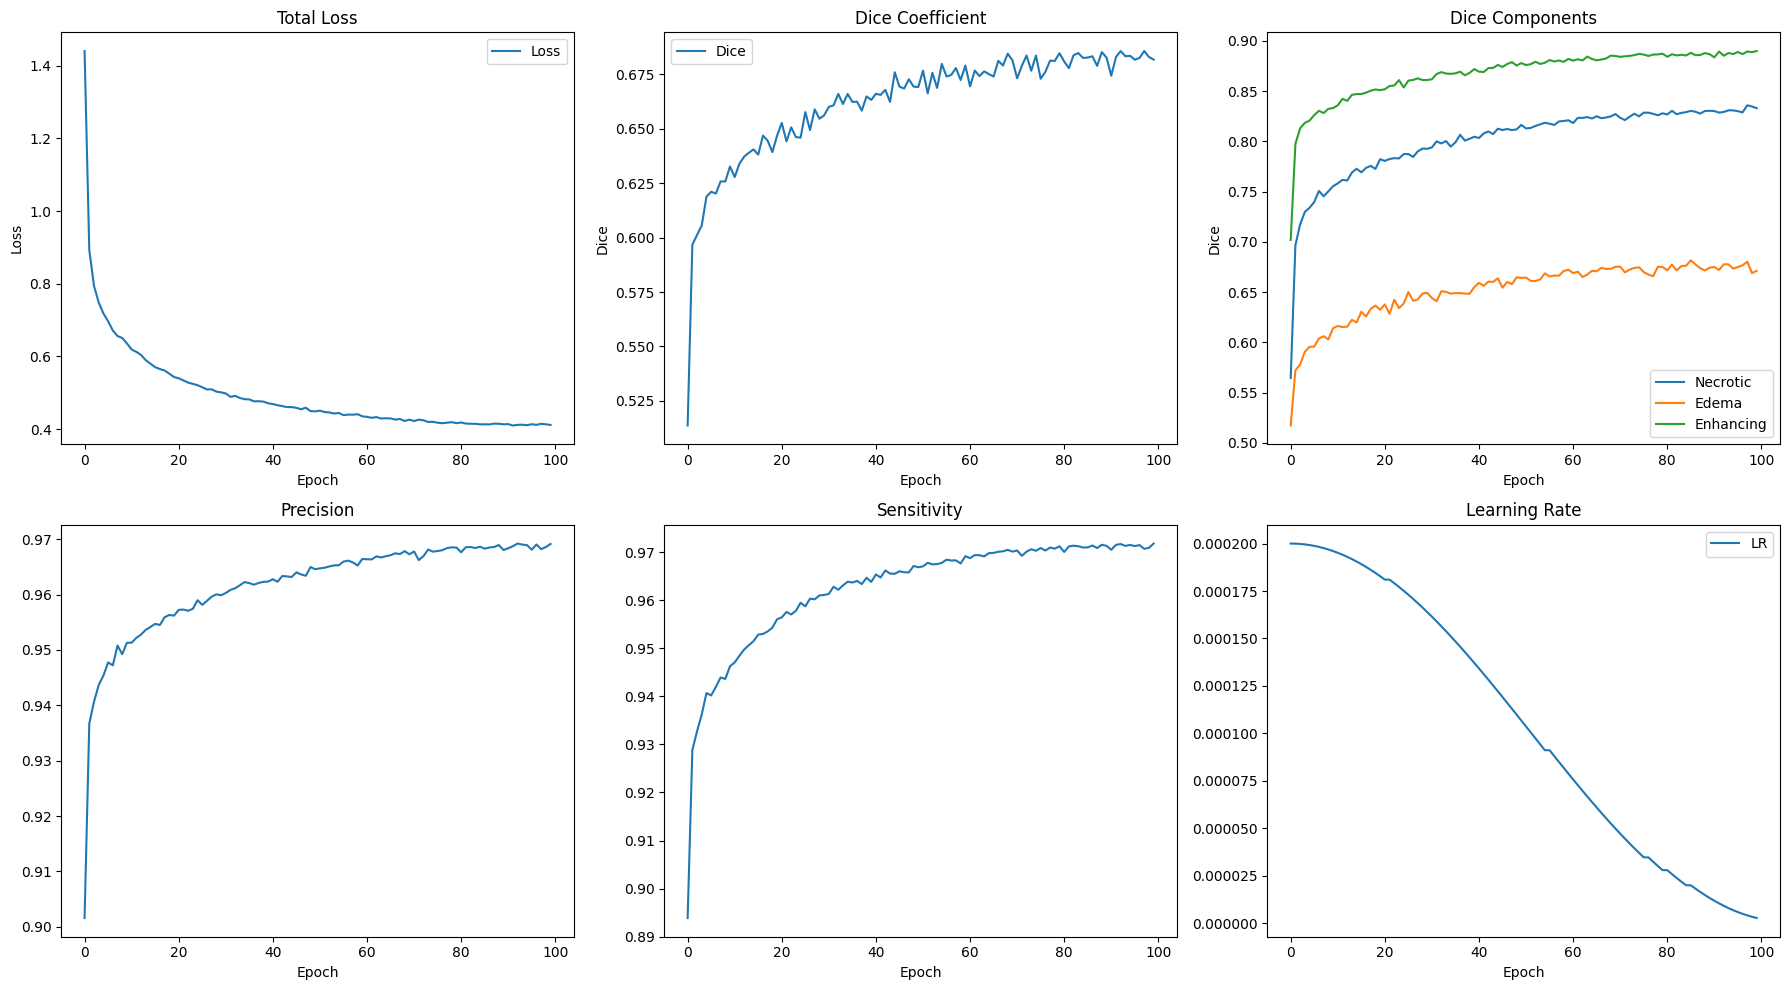

In [66]:
plot_history_from_csv("/home/nvsinh1/brats_segmentation/Pre-thesis/data/models_unet_novel/training_log.csv")